In [1]:
# --------------------------------------------------
# Standard library
# --------------------------------------------------
import os
import math
import time

# --------------------------------------------------
# PyTorch core
# --------------------------------------------------
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torch.autograd import gradcheck

# --------------------------------------------------
# Optimization & scheduling
# --------------------------------------------------
import torch.optim.lr_scheduler as lr_scheduler
from torch.optim.lr_scheduler import StepLR, _LRScheduler

# --------------------------------------------------
# Vision datasets
# --------------------------------------------------
from torchvision import datasets, transforms

# --------------------------------------------------
# Scientific & plotting
# --------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------
# Device configuration
# --------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
import torch
import torch.nn.functional as F
import numpy as np

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

### Training MAC-based networks

This section establishes a baseline: a standard multiply–accumulate (MAC) network trained with backpropagation. We will later replace the conventional MAC layers with π² layers

 Our goal is to match its accuracy using fundamentally different primitives: event timing, K-min selection, and differential competition

In [2]:
# --------------------------------------------------
# Reproducibility
# --------------------------------------------------
torch.manual_seed(42)
np.random.seed(42)


# --------------------------------------------------
# Dataset: MNIST
# --------------------------------------------------
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)


# --------------------------------------------------
# Network parameters (MAC baseline)
# --------------------------------------------------
input_dim = 28 * 28
hidden_dim = 50
output_dim = 10

lr = 0.1
epochs = 30

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


# --------------------------------------------------
# Manual weight initialization
# --------------------------------------------------
# We explicitly store weights as tensors (not nn.Modules)
# because π² layers will reuse these weights later.
W1 = torch.randn(hidden_dim, input_dim, device=device) * 0.01
W2 = torch.randn(output_dim, hidden_dim, device=device) * 0.01

W1.requires_grad_()
W2.requires_grad_()


# --------------------------------------------------
# Training loop
# --------------------------------------------------
for epoch in range(epochs):

    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        x = images.view(images.size(0), -1).to(device)
        y = labels.to(device)

        # Forward pass (MAC-based MLP)
        h = F.relu(F.linear(x, W1))
        logits = F.linear(h, W2)

        loss = F.cross_entropy(logits, y)
        total_loss += loss.item()

        # Backward pass
        loss.backward()

        # Manual SGD update
        with torch.no_grad():
            for W in (W1, W2):
                W -= lr * W.grad
                W.grad.zero_()

        # Training accuracy
        preds = torch.argmax(logits, dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    train_acc = 100.0 * correct / total
    avg_loss = total_loss / len(train_loader)

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train Loss: {avg_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}%"
    )


# --------------------------------------------------
# Test evaluation
# --------------------------------------------------
correct_test = 0
total_test = 0

with torch.no_grad():
    for images, labels in test_loader:
        x = images.view(images.size(0), -1).to(device)
        y = labels.to(device)

        h = F.relu(F.linear(x, W1))
        logits = F.linear(h, W2)

        preds = torch.argmax(logits, dim=1)
        correct_test += (preds == y).sum().item()
        total_test += y.size(0)

test_acc = 100.0 * correct_test / total_test
print(f"\nTest Accuracy (MAC baseline): {test_acc:.2f}%")


# --------------------------------------------------
# Save trained weights
# --------------------------------------------------
model_path = "mlp_weights.pth"
torch.save({"W1": W1, "W2": W2}, model_path)
print(f"Model saved to {model_path}")


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 484kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.51MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.1MB/s]


Epoch 01 | Train Loss: 0.8416 | Train Acc: 78.12%
Epoch 02 | Train Loss: 0.3295 | Train Acc: 90.64%
Epoch 03 | Train Loss: 0.2780 | Train Acc: 92.12%
Epoch 04 | Train Loss: 0.2390 | Train Acc: 93.25%
Epoch 05 | Train Loss: 0.2093 | Train Acc: 94.04%
Epoch 06 | Train Loss: 0.1865 | Train Acc: 94.72%
Epoch 07 | Train Loss: 0.1690 | Train Acc: 95.21%
Epoch 08 | Train Loss: 0.1549 | Train Acc: 95.56%
Epoch 09 | Train Loss: 0.1427 | Train Acc: 95.89%
Epoch 10 | Train Loss: 0.1325 | Train Acc: 96.20%
Epoch 11 | Train Loss: 0.1237 | Train Acc: 96.47%
Epoch 12 | Train Loss: 0.1160 | Train Acc: 96.70%
Epoch 13 | Train Loss: 0.1097 | Train Acc: 96.92%
Epoch 14 | Train Loss: 0.1033 | Train Acc: 97.04%
Epoch 15 | Train Loss: 0.0980 | Train Acc: 97.24%
Epoch 16 | Train Loss: 0.0936 | Train Acc: 97.28%
Epoch 17 | Train Loss: 0.0892 | Train Acc: 97.45%
Epoch 18 | Train Loss: 0.0850 | Train Acc: 97.55%
Epoch 19 | Train Loss: 0.0817 | Train Acc: 97.64%
Epoch 20 | Train Loss: 0.0781 | Train Acc: 97.70%


This visualization shows how a conventional MAC-based MLP organizes MNIST data in its hidden layer.
Later, you will directly compare this with π² hidden representations.

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


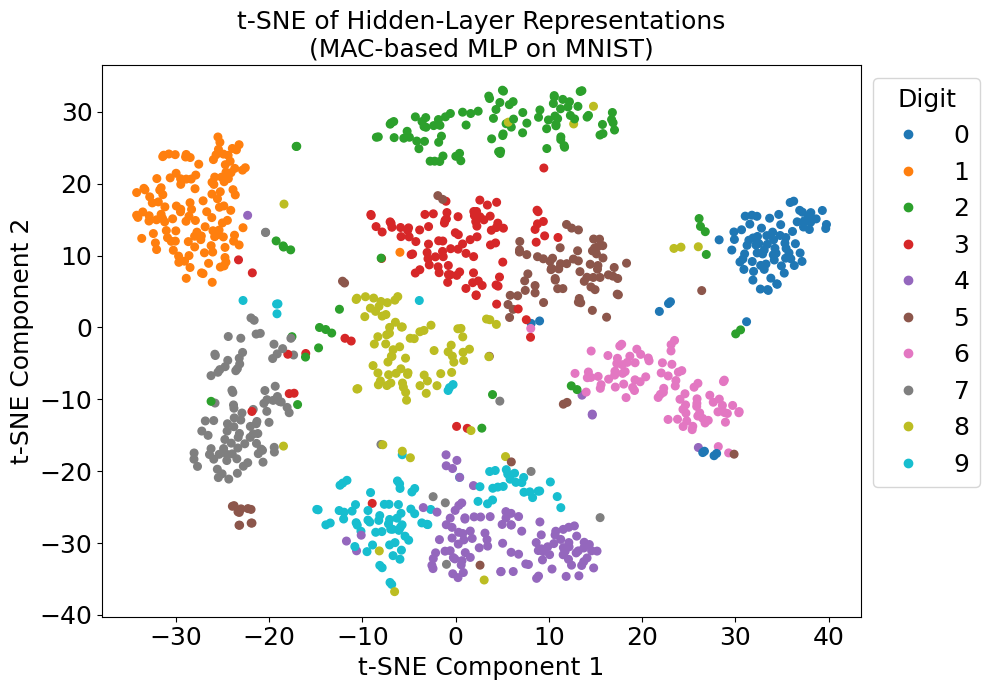

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.manifold import TSNE
from torch.utils.data import DataLoader
import torch.nn.functional as F


# --------------------------------------------------
# Collect hidden-layer activations from MLP
# --------------------------------------------------
hidden_acts = []
labels_all = []

max_samples = 1000  # limit for t-SNE stability
count = 0

test_loader_vis = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

with torch.no_grad():
    for image, label in test_loader_vis:
        image = image.to(device)
        image = image.flatten(start_dim=1)

        # Forward pass through MAC-based MLP
        h = F.relu(F.linear(image, W1))
        logits = F.linear(h, W2)

        hidden_acts.append(h.cpu().numpy())
        labels_all.append(label.cpu().numpy())

        count += 1
        if count == max_samples:
            break


# --------------------------------------------------
# Prepare data for t-SNE
# --------------------------------------------------
hidden_acts_np = np.array(hidden_acts).reshape(max_samples, -1)
labels_np = np.array(labels_all).reshape(-1)


# --------------------------------------------------
# Run t-SNE on hidden activations
# --------------------------------------------------
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_tsne = tsne.fit_transform(hidden_acts_np)


# --------------------------------------------------
# Plot t-SNE embedding
# --------------------------------------------------
font_size = 18
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=labels_np.astype(int),
    s=30,
    cmap="tab10"
)

# Legend outside the plot for clarity
plt.legend(
    *scatter.legend_elements(),
    title="Digit",
    fontsize=font_size,
    title_fontsize=font_size,
    loc="upper left",
    bbox_to_anchor=(1, 1)
)

plt.title(
    "t-SNE of Hidden-Layer Representations\n(MAC-based MLP on MNIST)",
    fontsize=font_size
)

plt.xlabel("t-SNE Component 1", fontsize=font_size)
plt.ylabel("t-SNE Component 2", fontsize=font_size)
plt.xticks(fontsize=font_size)
plt.yticks(fontsize=font_size)
plt.grid(False)

plt.tight_layout()
plt.show()


This t-SNE plot shows the geometry of the hidden layer learned by a conventional MAC-based MLP. Each point corresponds to one MNIST image, and colors denote digit classes. We see that the trained network organizes data into well-separated clusters

# $\pi^2_K$ Neuron







This function implements the core nonlinearity of a π² neuron. Instead of applying a pointwise activation, the neuron selects the K earliest (or smallest) events and averages them. This operation corresponds to event dropping and temporal integration in the time domain. The backward pass distributes gradients only to the selected events, enforcing sparsity and temporal competition during training.

In [5]:
import torch
from torch.autograd import gradcheck


class PIK(torch.autograd.Function):
    """
    K-min pooling primitive used in π² networks.

    Forward:
        Selects the K smallest values along dim=1 and returns their average.
        This corresponds to event-dropping + temporal averaging in π² neurons.

    Backward:
        Distributes the upstream gradient equally among the selected K entries.
        All other entries receive zero gradient.
    """

    @staticmethod
    def forward(ctx, in_mat, K):
        """
        Args:
            in_mat : Tensor of shape (B, N, M)
                     B = batch size
                     N = number of candidate events
                     M = output channels
            gamma  : K (number of earliest / smallest events to keep)

        Returns:
            Tensor of shape (B, M)
        """
        assert K >= 1, "gamma (K) must be >= 1"

        ctx.K = int(K)
        ctx.save_for_backward(in_mat)

        # Special case: K = 1 → pure minimum selection
        if K == 1:
            return torch.kthvalue(in_mat, 1, dim=1).values

        # Select K smallest values along the event dimension
        vals, _ = torch.topk(in_mat, K, dim=1, largest=False, sorted=False)

        # Average of the selected K events
        return vals.mean(dim=1)

    @staticmethod
    def backward(ctx, grad_output):
        """
        Gradient rule for K-min pooling.

        Each of the K selected elements receives grad_output / K.
        """
        (in_mat,) = ctx.saved_tensors
        K = ctx.K

        grad_input = torch.zeros_like(in_mat)

        # Identify the same K-min elements used in forward
        _, indices = torch.topk(in_mat, K, dim=1, largest=False, sorted=False)

        # Distribute gradient uniformly across selected indices
        grad_vals = (grad_output / K).unsqueeze(1).expand_as(indices)
        grad_input.scatter_(dim=1, index=indices, src=grad_vals)
        return grad_input, None


# --------------------------------------------------
# Sanity check: forward + backward
# --------------------------------------------------

batch_size, in_size, out_size = 1, 5, 1
K = 2

# Double precision required for gradcheck
input_tensor = torch.rand(
    batch_size, in_size, out_size,
    dtype=torch.float64,
    requires_grad=True
)

# input_tensor = input_tensor
print("Input:")
print(input_tensor)

# Forward pass
output = PIK.apply(input_tensor, K)
print("\nOutput:")
print(output)

# Backward pass with unit gradient
output.backward(torch.ones_like(output))
print("\nGradient w.r.t input:")
print(input_tensor.grad)


# --------------------------------------------------
# Numerical gradient verification
# --------------------------------------------------

print("\nRunning gradcheck...")
input_for_gradcheck = (input_tensor, K)

test_result = gradcheck(
    PIK.apply,
    input_for_gradcheck
)

print("Gradcheck passed:", test_result)


Input:
tensor([[[0.2544],
         [0.6308],
         [0.3539],
         [0.4416],
         [0.6128]]], dtype=torch.float64, requires_grad=True)

Output:
tensor([[0.3041]], dtype=torch.float64, grad_fn=<PIKBackward>)

Gradient w.r.t input:
tensor([[[0.5000],
         [0.0000],
         [0.5000],
         [0.0000],
         [0.0000]]], dtype=torch.float64)

Running gradcheck...
Gradcheck passed: True


This custom layer implements the core π² neuron. Each neuron receives multiple candidate events, applies learnable delays, and selects the K earliest events. Instead of a pointwise nonlinearity like ReLU, sparsity and nonlinearity arise from event competition in time.

In [8]:
class MPLayer_in_K(torch.nn.Module):
  def __init__(self,inp_node,out_node,K,diff=0):
    super().__init__()
    self.inp_node = inp_node
    self.out_node = out_node
    self.K = K
    self.diff = diff # differential inputs are given or not
    torch.manual_seed(43)
    self.weight = torch.nn.Parameter(torch.empty(inp_node, out_node), requires_grad=True)
    torch.nn.init.xavier_normal_(self.weight, gain=1.0)

  def spikeK(self, in_mat: torch.Tensor, K: int):
        assert K>=1
        if K == 1:
            return torch.kthvalue(in_mat, 1, dim=1).values
        vals, _ = torch.topk(in_mat, K, dim=1, largest=False, sorted=False)
        return vals.mean(dim=1)

  def forward(self, inputp, inputn=None):
      # Expand for broadcast
        inputp = inputp.unsqueeze(-1)
        # ----------------------------------------------
        # Differential input encoding
        # ----------------------------------------------
        if inputn is None:
            plus_in = F.relu(3.0 + inputp)
            minus_in = F.relu(3.0 - inputp)
        else:
            plus_in = inputp
            minus_in = inputn.unsqueeze(-1)

        # ----------------------------------------------
        # Differential weight encoding
        # ----------------------------------------------
        plus_w = F.relu(+ self.weight)
        minus_w = F.relu(- self.weight)

        # ----------------------------------------------
        # Event competition construction
        # ----------------------------------------------
        z_plus = torch.cat([plus_in + plus_w, minus_in + minus_w],dim=1)
        z_minus = torch.cat([plus_in + minus_w, minus_in + plus_w],dim=1)
        # ----------------------------------------------
        # K-min (π² neuron core)
        # ----------------------------------------------
        z_plus = self.spikeK(z_plus, self.K)
        z_minus = self.spikeK(z_minus, self.K)
        if self.diff == 0:
            return z_minus - z_plus
        else:
            return z_plus, z_minus

#FUNCTION TO COMPUTE THE CORRELATION
def Corr(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    x_centered = x
    #- x.mean(dim=1, keepdim=True)
    y_centered = y
    #- y.mean(dim=1, keepdim=True)
    numerator = torch.sum(x_centered * y_centered, dim=1)
    denominator = torch.sqrt(torch.sum(x_centered**2, dim=1)) * torch.sqrt(torch.sum(y_centered**2, dim=1))
    return numerator/ (denominator + 1e-6)

#Choosing the Value of K (π² Inference Study)


We sweep K and measure how closely π² hidden representations match those of a trained MAC-based MLP using Pearson correlation.

TOPK inference
[0.93457556 0.9465845  0.95590484 0.96328384 0.9692527  0.9741197
 0.97806454 0.9812791  0.98390776 0.9860539  0.98777264 0.989115
 0.9901402  0.9909021  0.9914365  0.99179316 0.9920029  0.9920942
 0.99208844 0.9920201 ]


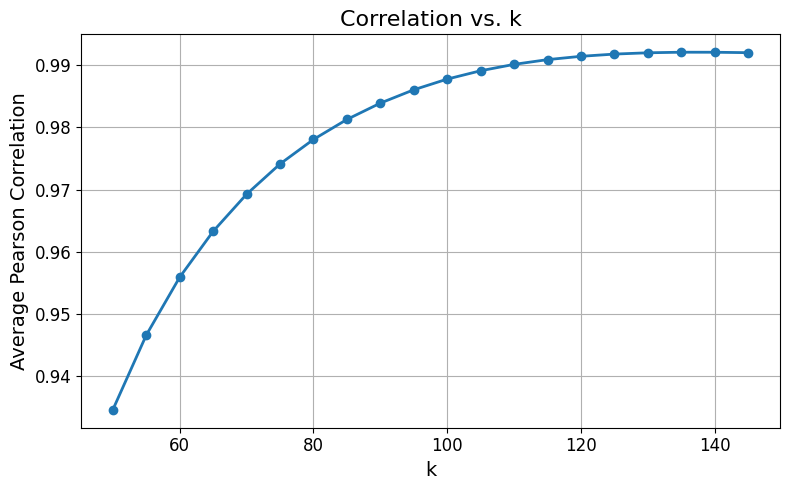

In [10]:
##Choosing the values of K
print("TOPK inference")
corr = []
test_loader1 = DataLoader(test_dataset, batch_size=10000, shuffle=False)
kend = 150
kstart = 50
kstep = 5
for k in range(kstart,kend,kstep):
    # print(k)
    K = [k, 16] #90
    layer1 = MPLayer_in_K(inp_node=input_dim, out_node=hidden_dim, K=K[0], diff=0)
    layer1.weight.data = W1.t().clone()
    layer2 = MPLayer_in_K(inp_node=hidden_dim, out_node=hidden_dim, K=K[1], diff=0)
    layer2.weight.data = W2.t().clone()
    scaling = 1
    with torch.no_grad():
        for images, labels in test_loader1:
            x = images.view(-1, input_dim).to(device)
            y = labels.to(device)
            h = F.relu(layer1(x)*scaling)
            logits = layer2(h)*scaling
            h_mlp = F.relu(F.linear(x, W1))
            logits_mlp = F.linear(h_mlp, W2)

    correlations = Corr(h_mlp, h)
    c = torch.mean(correlations)
    corr.append(c)
corr_tensor = torch.stack(corr).cpu().numpy()
print(corr_tensor)
k_values = list(range(kstart, kend, kstep))
plt.figure(figsize=(8, 5))
plt.plot(k_values, corr_tensor, marker='o', linewidth=2)
plt.xlabel('k', fontsize=14)
plt.ylabel('Average Pearson Correlation', fontsize=14)
plt.title('Correlation vs. k', fontsize=16)
plt.grid(True)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

TOPK inference
[0.509103   0.7061313  0.73960847 0.73382795 0.7321075  0.7318467
 0.73137355 0.7247943  0.71123546 0.70675164]


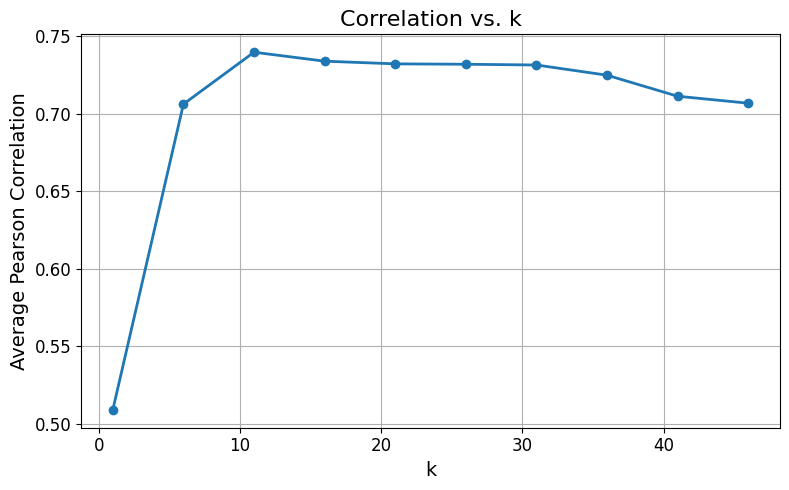

In [11]:
print("TOPK inference")
corr = []
test_loader1 = DataLoader(test_dataset, batch_size=10000, shuffle=False)
kend = 50
kstart = 1
kstep = 5
for k in range(kstart,kend,kstep):
    # print(k)
    K = [140, k] #90
    layer1 = MPLayer_in_K(inp_node=input_dim, out_node=hidden_dim, K=K[0], diff=0)
    layer1.weight.data = W1.t().clone()
    layer2 = MPLayer_in_K(inp_node=hidden_dim, out_node=output_dim, K=K[1], diff=0)
    layer2.weight.data = W2.t().clone()
    scaling = 1
    with torch.no_grad():
        for images, labels in test_loader1:
            x = images.view(-1, input_dim).to(device)
            y = labels.to(device)
            h = F.relu(layer1(x)*scaling)
            logits = layer2(h)*scaling
            h_mlp = F.relu(F.linear(x, W1))
            logits_mlp = F.linear(h_mlp, W2)
    correlations = Corr(logits_mlp, logits)
    c = torch.mean(correlations)
    corr.append(c)
corr_tensor = torch.stack(corr).cpu().numpy()
print(corr_tensor)
k_values = list(range(kstart, kend, kstep))
plt.figure(figsize=(8, 5))
plt.plot(k_values, corr_tensor, marker='o', linewidth=2)
plt.xlabel('k', fontsize=14)
plt.ylabel('Average Pearson Correlation', fontsize=14)
plt.title('Correlation vs. k', fontsize=16)
plt.grid(True)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

Fining the values of K for the output layer...
The output layer shows lower correlation because π² introduces an approximation error when replacing MAC accumulation with K-min selection, and this error compounds at the final layer.

Here we fix K and evaluate π² inference accuracy. Despite replacing MACs with event dropping, the network retains high accuracy.
The scaling parameter controls the separation between the classes. Observe the effect of the scaling parameter on the confusion matrix.


Train Accuracy: 89.01%


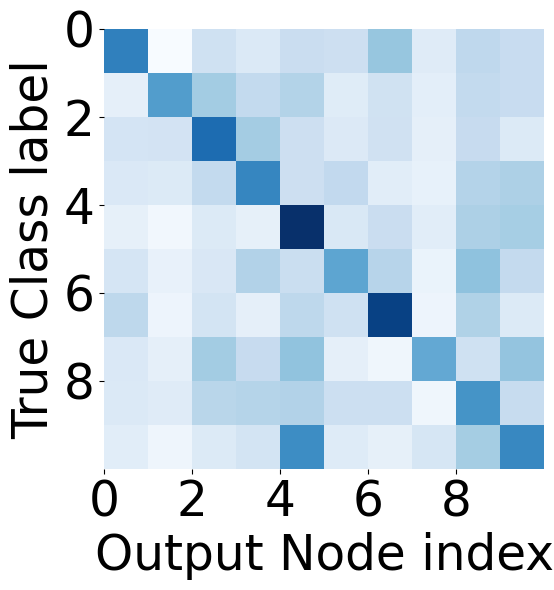

In [14]:
K = [140,16] #90
layer1 = MPLayer_in_K(inp_node=input_dim, out_node=hidden_dim, K=K[0], diff=0)
layer1.weight.data = W1.t().clone()
layer2 = MPLayer_in_K(inp_node=hidden_dim, out_node=output_dim, K=K[1], diff=0)
layer2.weight.data = W2.t().clone()
correct_test = 0
total_test = 0
scaling = 30
with torch.no_grad():
    for images, labels in train_loader:
        x = images.view(-1, input_dim).to(device)
        y = labels.to(device)

        h = F.relu(layer1(x)*scaling)
        logits = layer2(h)*scaling
        preds = torch.argmax(logits, dim=1)

        correct_test += (preds == y).sum().item()
        total_test += y.size(0)

test_acc = correct_test / total_test * 100
print(f"\nTrain Accuracy: {test_acc:.2f}%")


#confusion matrix
test_loader2 = DataLoader(test_dataset, batch_size=10000, shuffle=False)
# Concatenate entire test set for easy batch evaluation
images, labels = next(iter(test_loader2))
X_tensor = images.view(-1, 28 * 28)
Y_tensor = labels
output_dim = 10  # For MNIST 0-9
# Compute output activations
scaling = 10
with torch.no_grad():
    h = scaling*F.relu(layer1(X_tensor.to(device)))
    logits = scaling*layer2(h)
    probs = torch.softmax(logits, dim=1)  # Cross-entropy used => softmax output

# Initialize class-wise average activation matrix
avg_output_activation = torch.zeros((output_dim, output_dim))

# Compute per-class output activation average
for cls in range(output_dim):
    idx = (Y_tensor == cls)
    class_probs = probs[idx]  # Shape: (num_samples_in_class, output_dim)
    avg_output_activation[cls] = class_probs.mean(dim=0)

# Plot
plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    avg_output_activation.numpy(),
    cmap="Blues",
    xticklabels=False,
    yticklabels=False,
    cbar=False,
    square=True,
)
# Control tick label font sizes
fsize = 35
plt.xticks(fontsize=fsize)
plt.yticks(fontsize=fsize)
ax.set_xlabel("Output Node index", fontsize=fsize)
ax.set_ylabel("True Class label", fontsize=fsize)
tick_indices = list(range(0, output_dim, 2))  # Every 2nd label: 0, 2, 4, 6, 8

# Set custom tick locations and labels
ax.set_xticks(tick_indices)
ax.set_xticklabels([str(i) for i in tick_indices], fontsize=fsize)
ax.set_yticks(tick_indices)
ax.set_yticklabels([str(i) for i in tick_indices], fontsize=fsize)

plt.tight_layout()
plt.show()

Here we visualize the hidden-layer representations of a π² network initialized from a trained MAC model, before any π² fine-tuning. Despite replacing dot products with Top-K event selection, we observe that much of the class structure is already preserved.

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


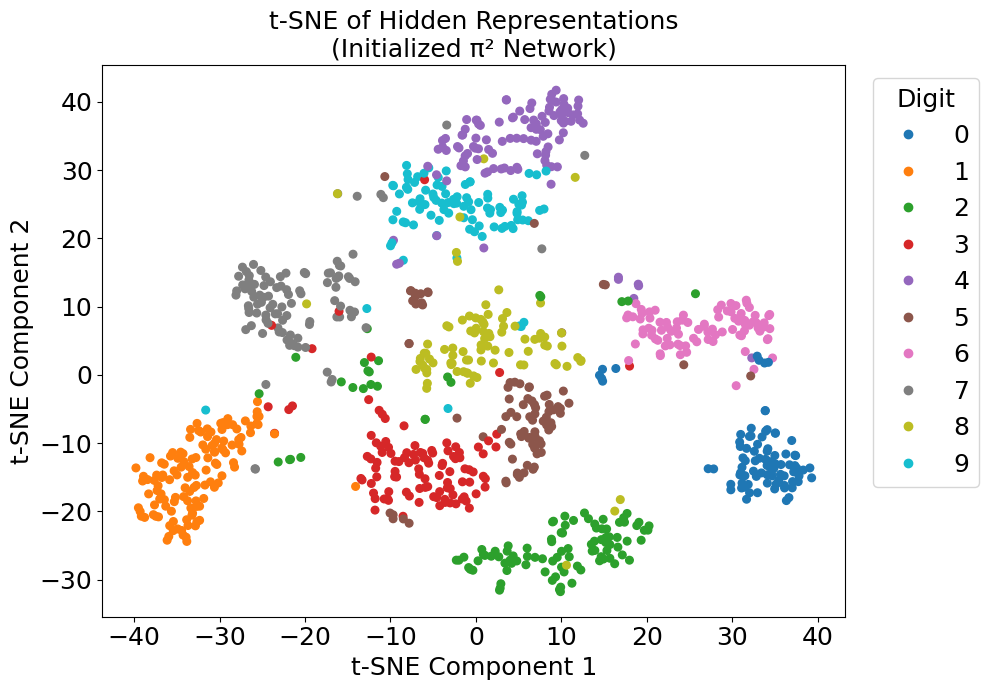

In [15]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.manifold import TSNE


# --------------------------------------------------
# π² configuration
# --------------------------------------------------
K = [140, 16]
scaling = 30
max_samples = 1000

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# --------------------------------------------------
# Initialize π² layers from MAC weights
# --------------------------------------------------
layer1_init = MPLayer_in_K(
    inp_node=input_dim,
    out_node=hidden_dim,
    K=K[0],
    diff=0
).to(device)

layer2_init = MPLayer_in_K(
    inp_node=hidden_dim,
    out_node=output_dim,
    K=K[1],
    diff=0
).to(device)

# Safe weight transfer
with torch.no_grad():
    layer1_init.weight.copy_(W1.t())
    layer2_init.weight.copy_(W2.t())


# --------------------------------------------------
# Collect hidden representations
# --------------------------------------------------
hidden_acts = []
labels_all = []

test_loader_vis = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    pin_memory=True
)

count = 0
with torch.no_grad():
    for image, label in test_loader_vis:
        image = image.view(1, -1).to(device)

        h = F.relu(scaling * layer1_init(image))

        hidden_acts.append(h.cpu().numpy())
        labels_all.append(label.cpu().numpy())

        count += 1
        if count == max_samples:
            break


# --------------------------------------------------
# Prepare data for t-SNE
# --------------------------------------------------
hidden_np = np.array(hidden_acts).reshape(max_samples, -1)
labels_np = np.array(labels_all).reshape(-1)


# --------------------------------------------------
# Run t-SNE on hidden activations
# --------------------------------------------------
tsne = TSNE(
    n_components=2,
    perplexity=30,
    n_iter=1000,
    random_state=42
)

X_tsne_hidden = tsne.fit_transform(hidden_np)


# --------------------------------------------------
# Plot
# --------------------------------------------------
fsize = 18
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_tsne_hidden[:, 0],
    X_tsne_hidden[:, 1],
    c=labels_np.astype(int),
    s=30,
    cmap="tab10"
)

plt.legend(
    *scatter.legend_elements(),
    title="Digit",
    fontsize=fsize,
    title_fontsize=fsize,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0)
)

plt.title(
    "t-SNE of Hidden Representations\n(Initialized π² Network)",
    fontsize=fsize
)
plt.xlabel("t-SNE Component 1", fontsize=fsize)
plt.ylabel("t-SNE Component 2", fontsize=fsize)

plt.xticks(fontsize=fsize)
plt.yticks(fontsize=fsize)
plt.grid(False)
plt.tight_layout()
plt.show()


#Training $\pi^2$ Networks
Can we fine-tune π² / Top-K networks with gradient descent,to improve accuracy and match the baseline ?

In [16]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


# --------------------------------------------------
# π² network configuration
# --------------------------------------------------
K = [140, 16]          # K for hidden layer, K for output layer
scaling = 30           # temporal scaling factor
lr = 0.1
epochs = 20

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# --------------------------------------------------
# π² layers initialized from MAC weights
# --------------------------------------------------
layer1 = MPLayer_in_K(
    inp_node=input_dim,
    out_node=hidden_dim,
    K=K[0],
    diff=0
).to(device)

layer2 = MPLayer_in_K(
    inp_node=hidden_dim,
    out_node=output_dim,
    K=K[1],
    diff=0
).to(device)

# Copy pretrained MAC weights
with torch.no_grad():
    layer1.weight.copy_(W1.t())
    layer2.weight.copy_(W2.t())


# --------------------------------------------------
# Optimizer
# --------------------------------------------------
optimizer = torch.optim.SGD(
    list(layer1.parameters()) + list(layer2.parameters()),
    lr=lr
)


# --------------------------------------------------
# Data loaders
# --------------------------------------------------
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)


# --------------------------------------------------
# Tracking metrics
# --------------------------------------------------
train_acc_list = []
test_acc_list = []
loss_list = []


# --------------------------------------------------
# Training loop (π² fine-tuning)
# --------------------------------------------------
for epoch in range(epochs):

    layer1.train()
    layer2.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        x = images.view(images.size(0), -1).to(device)
        y = labels.to(device)

        # π² forward pass with scaling
        h = F.relu(scaling * layer1(x))
        logits = scaling * layer2(h)

        loss = F.cross_entropy(logits, y)
        total_loss += loss.item()

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        preds = torch.argmax(logits, dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    train_acc = 100.0 * correct / total
    train_loss = total_loss / len(train_loader)

    train_acc_list.append(train_acc)
    loss_list.append(train_loss)

    # --------------------------------------------------
    # Test evaluation
    # --------------------------------------------------
    layer1.eval()
    layer2.eval()

    correct_test = 0
    total_test = 0

    with torch.no_grad():
        for images, labels in test_loader:
            x = images.view(images.size(0), -1).to(device)
            y = labels.to(device)

            h = F.relu(scaling * layer1(x))
            logits = scaling * layer2(h)

            preds = torch.argmax(logits, dim=1)
            correct_test += (preds == y).sum().item()
            total_test += y.size(0)

    test_acc = 100.0 * correct_test / total_test
    test_acc_list.append(test_acc)

    print(
        f"Epoch {epoch+1:02d} | "
        f"Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Test Acc: {test_acc:.2f}%"
    )


Epoch 01 | Loss: 0.1463 | Train Acc: 96.39% | Test Acc: 96.62%
Epoch 02 | Loss: 0.1138 | Train Acc: 97.00% | Test Acc: 96.69%
Epoch 03 | Loss: 0.1037 | Train Acc: 97.21% | Test Acc: 96.84%
Epoch 04 | Loss: 0.0972 | Train Acc: 97.40% | Test Acc: 96.99%
Epoch 05 | Loss: 0.0923 | Train Acc: 97.53% | Test Acc: 96.94%
Epoch 06 | Loss: 0.0883 | Train Acc: 97.63% | Test Acc: 96.96%
Epoch 07 | Loss: 0.0848 | Train Acc: 97.71% | Test Acc: 97.01%
Epoch 08 | Loss: 0.0817 | Train Acc: 97.83% | Test Acc: 97.07%
Epoch 09 | Loss: 0.0789 | Train Acc: 97.90% | Test Acc: 97.13%
Epoch 10 | Loss: 0.0765 | Train Acc: 97.99% | Test Acc: 97.20%
Epoch 11 | Loss: 0.0742 | Train Acc: 98.06% | Test Acc: 97.18%
Epoch 12 | Loss: 0.0721 | Train Acc: 98.13% | Test Acc: 97.26%
Epoch 13 | Loss: 0.0703 | Train Acc: 98.17% | Test Acc: 97.21%
Epoch 14 | Loss: 0.0684 | Train Acc: 98.23% | Test Acc: 97.30%
Epoch 15 | Loss: 0.0668 | Train Acc: 98.33% | Test Acc: 97.32%
Epoch 16 | Loss: 0.0653 | Train Acc: 98.36% | Test Acc:

This t-SNE plot shows the hidden-layer representations of the π² network after fine-tuning. Compared to the initialized π² model, clusters are tighter and more class-separable

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


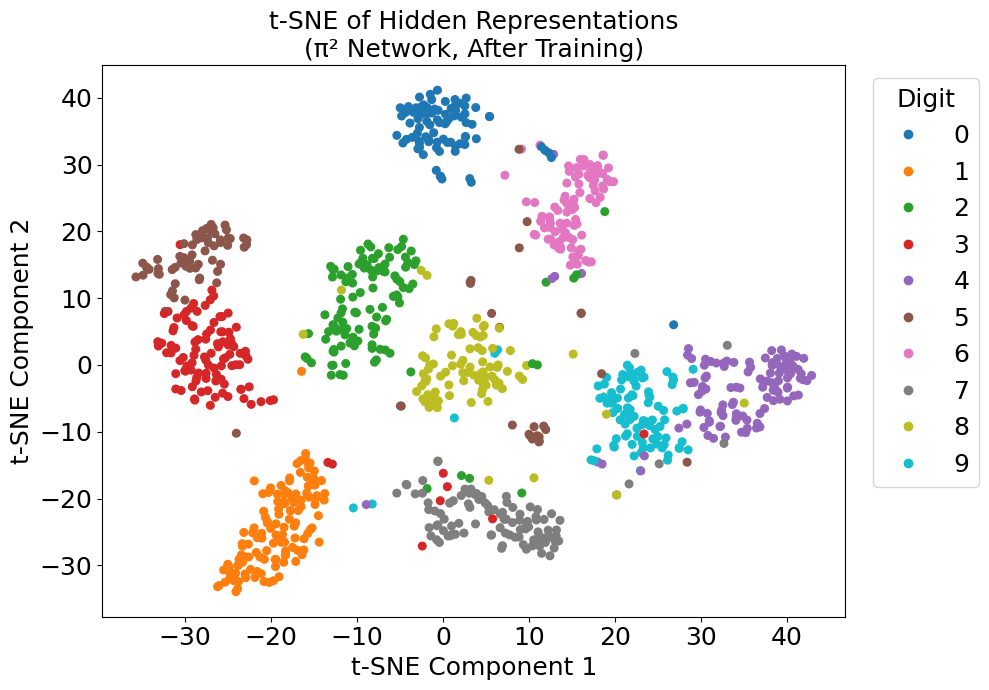

In [17]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.manifold import TSNE


# --------------------------------------------------
# Configuration
# --------------------------------------------------
K = [140, 16]
scaling = 30
max_samples = 1000

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# --------------------------------------------------
# Initialize π² layers from *trained π² weights*
# --------------------------------------------------
layer1_init = MPLayer_in_K(
    inp_node=input_dim,
    out_node=hidden_dim,
    K=K[0],
    diff=0
).to(device)

layer2_init = MPLayer_in_K(
    inp_node=hidden_dim,
    out_node=output_dim,
    K=K[1],
    diff=0
).to(device)

# Copy weights from trained π² layers
with torch.no_grad():
    layer1_init.weight.copy_(layer1.weight)
    layer2_init.weight.copy_(layer2.weight)


# --------------------------------------------------
# Collect hidden representations
# --------------------------------------------------
hidden_acts = []
labels_all = []

test_loader_vis = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    pin_memory=True
)

count = 0
with torch.no_grad():
    for image, label in test_loader_vis:
        image = image.view(1, -1).to(device)

        # π² forward pass
        h = F.relu(scaling * layer1_init(image))

        hidden_acts.append(h.cpu().numpy())
        labels_all.append(label.cpu().numpy())

        count += 1
        if count == max_samples:
            break


# --------------------------------------------------
# Prepare data for t-SNE
# --------------------------------------------------
hidden_np = np.array(hidden_acts).reshape(max_samples, -1)
labels_np = np.array(labels_all).reshape(-1)


# --------------------------------------------------
# Run t-SNE
# --------------------------------------------------
tsne = TSNE(
    n_components=2,
    perplexity=30,
    n_iter=1000,
    random_state=42
)

X_tsne_k1 = tsne.fit_transform(hidden_np)


# --------------------------------------------------
# Plot
# --------------------------------------------------
fsize = 18
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_tsne_k1[:, 0],
    X_tsne_k1[:, 1],
    c=labels_np.astype(int),
    s=30,
    cmap="tab10"
)

plt.legend(
    *scatter.legend_elements(),
    title="Digit",
    fontsize=fsize,
    title_fontsize=fsize,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0)
)

plt.title(
    "t-SNE of Hidden Representations\n(π² Network, After Training)",
    fontsize=fsize
)
plt.xlabel("t-SNE Component 1", fontsize=fsize)
plt.ylabel("t-SNE Component 2", fontsize=fsize)

plt.xticks(fontsize=fsize)
plt.yticks(fontsize=fsize)
plt.grid(False)
plt.tight_layout()
plt.show()


#Quantizing $\pi^2$ Networks
We quantize π² weights to 3 bits using symmetric uniform quantization.

In [ ]:
import torch
import torch.nn.functional as F

# --------------------------------------------------
# Symmetric signed quantization
# --------------------------------------------------
def symmetric_quantize(tensor, n_bits=3):
    """
    Symmetric uniform quantization with dequantization.

    Args:
        tensor : floating-point tensor
        n_bits : number of bits (e.g., 4 → range [-7, 7])

    Returns:
        dq_tensor : dequantized tensor (float)
        q_tensor  : integer quantized tensor
    """
    qmax = 2 ** (n_bits) - 1  # e.g., 7 for 4-bit
    abs_max = tensor.abs().max()

    scale = abs_max / qmax
    q_tensor = (tensor / scale).round().clamp(-qmax, qmax)
    dq_tensor = q_tensor * scale

    return dq_tensor, q_tensor


# --------------------------------------------------
# Quantize trained π² weights
# --------------------------------------------------
n_bits = 3

with torch.no_grad():
    W1_q, q1 = symmetric_quantize(layer1.weight, n_bits=n_bits)
    W2_q, q2 = symmetric_quantize(layer2.weight, n_bits=n_bits)


# --------------------------------------------------
# Sanity check: quantized integer range
# --------------------------------------------------
print("Layer 1 q range:", q1.min().item(), q1.max().item())
print("Layer 2 q range:", q2.min().item(), q2.max().item())


# --------------------------------------------------
# Create quantized π² layers
# --------------------------------------------------
layer1_q = MPLayer_in_K(
    inp_node=input_dim,
    out_node=hidden_dim,
    K=K[0],          # FIX: gamma, not K
    diff=0
).to(device)

layer2_q = MPLayer_in_K(
    inp_node=hidden_dim,
    out_node=output_dim,
    K=K[1],          # FIX: gamma, not K
    diff=0
).to(device)

# Load quantized (dequantized) weights
with torch.no_grad():
    layer1_q.weight.copy_(W1_q)
    layer2_q.weight.copy_(W2_q)


# --------------------------------------------------
# Evaluate quantized π² network
# --------------------------------------------------
correct, total = 0, 0

with torch.no_grad():
    for images, labels in test_loader:
        x = images.view(images.size(0), -1).to(device)
        y = labels.to(device)

        h = F.relu(scaling * layer1_q(x))
        logits = scaling * layer2_q(h)

        preds = torch.argmax(logits, dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

test_acc = 100.0 * correct / total
test_acc_list.append(test_acc)

print(f"Test Accuracy (π², {n_bits}-bit weights): {test_acc:.2f}%")


Layer 1 q range: -7.0 6.0
Layer 2 q range: -7.0 7.0
Test Accuracy (π², 3-bit weights): 96.78%


#Naive Training of $\pi^2$ networks
π² networks can be trained from scratch, without MAC initialization

In [ ]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


# --------------------------------------------------
# Configuration
# --------------------------------------------------
K = [140, 16]
scaling = 30
lr = 0.1
epochs = 30

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# --------------------------------------------------
# π² layers (NO initialization from MAC weights)
# --------------------------------------------------
layer11 = MPLayer_in_K(
    inp_node=input_dim,
    out_node=hidden_dim,
    K=K[0],
    diff=0         # IMPORTANT: return (zPlus, zMinus)
).to(device)

layer22 = MPLayer_in_K(
    inp_node=hidden_dim,
    out_node=output_dim,
    K=K[1],
    diff=0
).to(device)


# --------------------------------------------------
# Optimizer
# --------------------------------------------------
optimizer = torch.optim.SGD(
    list(layer11.parameters()) + list(layer22.parameters()),
    lr=lr
)


# --------------------------------------------------
# Data loaders
# --------------------------------------------------
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)


# --------------------------------------------------
# Tracking
# --------------------------------------------------
train_acc_list = []
test_acc_list = []
loss_list = []


# --------------------------------------------------
# Training loop
# --------------------------------------------------
for epoch in range(epochs):

    layer11.train()
    layer22.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        x = images.view(images.size(0), -1).to(device)
        y = labels.to(device)

        # --------------------------------------------------
        # π² forward pass (explicit differential signals)
        # --------------------------------------------------
        h = F.relu(layer11(x))                 # (+) and (−) events
        logits = scaling * layer22(h*scaling) # second π² layer

        loss = F.cross_entropy(logits, y)
        total_loss += loss.item()

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        preds = torch.argmax(logits, dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    train_acc = 100.0 * correct / total
    train_loss = total_loss / len(train_loader)

    train_acc_list.append(train_acc)
    loss_list.append(train_loss)

    # --------------------------------------------------
    # Evaluation
    # --------------------------------------------------
    layer1.eval()
    layer2.eval()

    correct_test = 0
    total_test = 0

    with torch.no_grad():
        for images, labels in test_loader:
            x = images.view(images.size(0), -1).to(device)
            y = labels.to(device)

            h = F.relu(layer11(x))
            logits = scaling * layer22(h*scaling)

            preds = torch.argmax(logits, dim=1)
            correct_test += (preds == y).sum().item()
            total_test += y.size(0)

    test_acc = 100.0 * correct_test / total_test
    test_acc_list.append(test_acc)

    print(
        f"Epoch {epoch+1:02d} | "
        f"Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Test Acc: {test_acc:.2f}%"
    )


Epoch 01 | Loss: 0.4398 | Train Acc: 88.34% | Test Acc: 92.90%
Epoch 02 | Loss: 0.2453 | Train Acc: 93.13% | Test Acc: 93.86%
Epoch 03 | Loss: 0.2043 | Train Acc: 94.29% | Test Acc: 94.41%
Epoch 04 | Loss: 0.1804 | Train Acc: 94.99% | Test Acc: 94.79%
Epoch 05 | Loss: 0.1641 | Train Acc: 95.50% | Test Acc: 95.07%
Epoch 06 | Loss: 0.1518 | Train Acc: 95.78% | Test Acc: 95.24%
Epoch 07 | Loss: 0.1423 | Train Acc: 96.12% | Test Acc: 95.49%
Epoch 08 | Loss: 0.1343 | Train Acc: 96.33% | Test Acc: 95.58%
Epoch 09 | Loss: 0.1275 | Train Acc: 96.52% | Test Acc: 95.72%
Epoch 10 | Loss: 0.1218 | Train Acc: 96.70% | Test Acc: 95.79%
Epoch 11 | Loss: 0.1166 | Train Acc: 96.86% | Test Acc: 95.79%
Epoch 12 | Loss: 0.1122 | Train Acc: 96.99% | Test Acc: 95.96%
Epoch 13 | Loss: 0.1081 | Train Acc: 97.15% | Test Acc: 96.02%
Epoch 14 | Loss: 0.1043 | Train Acc: 97.26% | Test Acc: 96.08%
Epoch 15 | Loss: 0.1011 | Train Acc: 97.34% | Test Acc: 96.08%
Epoch 16 | Loss: 0.0979 | Train Acc: 97.44% | Test Acc:

#Profiling the $\pi^2$ code

In [ ]:
# Test the layer
from torch.profiler import profile, record_function, ProfilerActivity
batch_size = 128
input_dim = 1000
output_dim = 100
K = 520
model = MPLayer_in_K(inp_node=input_dim, out_node=output_dim, K=K)
dummy_input = torch.randn(batch_size, input_dim)
model.weight.data.copy_(torch.rand(input_dim, output_dim))
# # Forward pass
# output = model(dummy_input)
# print("Output:\n", output)
# print("Output shape:", output.shape)

device = "cpu"
model = model.to(device)
input_tensor = dummy_input.to(device)

for i in range(10):
  with profile(activities=[ProfilerActivity.CPU],
          profile_memory=True, record_shapes=True,with_stack=True) as prof:
      o = model(input_tensor.to(device))

  print(prof.key_averages().table(sort_by="self_cpu_memory_usage", row_limit=10))

-----------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg       CPU Mem  Self CPU Mem    # of Calls  
-----------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
              aten::add         5.36%     140.111ms         5.36%     140.149ms      28.030ms     195.80 MB     195.80 MB             5  
              aten::cat         4.71%     123.321ms         4.71%     123.321ms      61.660ms     195.31 MB     195.31 MB             2  
             aten::topk        89.44%        2.340s        89.44%        2.340s        1.170s     152.34 MB     152.34 MB             2  
        aten::clamp_min         0.04%       1.141ms         0.04%       1.141ms     285.169us       1.74 MB       1.74 MB             4  
              aten::sub         0.

In [ ]:

# Test the layer
from torch.profiler import profile, record_function, ProfilerActivity
batch_size = 128
input_dim = 1000
output_dim = 100

model =torch.nn.Linear(input_dim,output_dim,bias=False)
# Generate dummy input with specified batch size and input dimension
dummy_input = torch.randn(batch_size, input_dim)
# print("Input:\n", dummy_input)
# # Correct weight assignment
# print("Weight:\n",torch.rand(output_dim, input_dim))
model.weight.data.copy_(torch.rand(output_dim, input_dim))



device = "cpu"
model = model.to(device)
input_tensor = dummy_input.to(device)

for i in range(10):
  with profile(activities=[ProfilerActivity.CPU],
          profile_memory=True, record_shapes=True,with_stack=True) as prof:
      output2 = F.relu(model(input_tensor.to(device)))

  print(prof.key_averages().table(sort_by="self_cpu_memory_usage", row_limit=10))


----------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                  Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg       CPU Mem  Self CPU Mem    # of Calls  
----------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
              aten::mm        99.58%      42.634ms        99.58%      42.636ms      42.636ms      50.00 KB      50.00 KB             1  
       aten::clamp_min         0.09%      40.349us         0.09%      40.349us      40.349us      50.00 KB      50.00 KB             1  
              aten::to         0.02%       7.500us         0.02%       7.500us       7.500us           0 B           0 B             1  
          aten::linear         0.03%      14.597us        99.80%      42.729ms      42.729ms      50.00 KB           0 B             1  
               aten::t         0.08%     